In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('M25 - Data Analytics I Assignment-1/M25_DA_A1_Dataset1.csv')

In [2]:
df.head()


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [3]:
# Show missing values + data types+ cat/numerical data together
missing_info = pd.DataFrame({
    "Missing_Values": df.isnull().sum(),
    "Data_Type": df.dtypes,
    "Category": ["Numerical" if pd.api.types.is_numeric_dtype(df[col]) else "Categorical" for col in df.columns]

})


print(missing_info)


                Missing_Values Data_Type     Category
Age                          0    object  Categorical
Workclass                 2800    object  Categorical
fnlwgt                       1   float64    Numerical
Education                    1    object  Categorical
Education_Num                1   float64    Numerical
Martial_Status               1    object  Categorical
Occupation                2810    object  Categorical
Relationship                 1    object  Categorical
Race                         1    object  Categorical
Sex                          1    object  Categorical
Capital_Gain                 1   float64    Numerical
Capital_Loss                 1   float64    Numerical
Hours_per_week               1   float64    Numerical
Country                    858    object  Categorical
Target                       1    object  Categorical


In [4]:
# Fills missing values in categorical columns with the most frequent value (mode)
categorical_cols=['Workclass','Education' ,'Martial_Status','Relationship','Race','Sex','Occupation', 'Target','Country']
for col in categorical_cols:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
print(df.isnull().sum())


Age               0
Workclass         0
fnlwgt            1
Education         0
Education_Num     1
Martial_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      1
Capital_Loss      1
Hours_per_week    1
Country           0
Target            0
dtype: int64


In [5]:
# Fill numerical columns with median
df.columns = df.columns.str.strip()

num_cols = ['fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']

for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print(df.isnull().sum())

Age               0
Workclass         0
fnlwgt            0
Education         0
Education_Num     0
Martial_Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital_Gain      0
Capital_Loss      0
Hours_per_week    0
Country           0
Target            0
dtype: int64


In [6]:
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 29
Duplicate rows after removal: 0


# Q1

In [7]:
education_counts = df["Education"].value_counts()
print("Unique Education Levels and Frequencies:\n", education_counts)

Unique Education Levels and Frequencies:
 Education
 HS-grad         15778
 Some-college    10869
 Bachelors        8020
 Masters          2656
 Assoc-voc        2060
 11th             1812
 Assoc-acdm       1601
 10th             1389
 7th-8th           954
 Prof-school       834
 9th               756
 12th              656
 Doctorate         594
 5th-6th           508
 1st-4th           245
 Preschool          82
Name: count, dtype: int64


In [8]:
education_mapping = {
    "Preschool": "Elementary",

    "1st-4th": "Primary School",
    "5th-6th": "Primary School",

    "7th-8th": "Secondary School",
    "9th": "Secondary School",
    "10th": "Secondary School",
    "11th": "Secondary School",
    "12th": "Secondary School",
    "HS-grad": "Secondary School",

    "Some-college": "Undergraduate",
    "Assoc-voc": "Undergraduate",
    "Assoc-acdm": "Undergraduate",
    "Bachelors": "Undergraduate",

    "Masters": "Postgraduate",
    "Doctorate": "Postgraduate",

    "Prof-school": "Professional"
}

df["Education"] = df["Education"].str.strip()

# Grouped Education Counts
df["Grouped"] = df["Education"].map(education_mapping)
edu_group_counts = df["Grouped"].value_counts()

print("\nGrouped Education Levels and Frequencies:\n", edu_group_counts)



Grouped Education Levels and Frequencies:
 Grouped
Undergraduate       22550
Secondary School    21345
Postgraduate         3250
Professional          834
Primary School        753
Elementary             82
Name: count, dtype: int64


/tmp/ipykernel_22633/1955096427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=education_counts.index, y=education_counts.values, palette="viridis")
/tmp/ipykernel_22633/1955096427.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_group_counts.index, y=edu_group_counts.values, palette="magma")


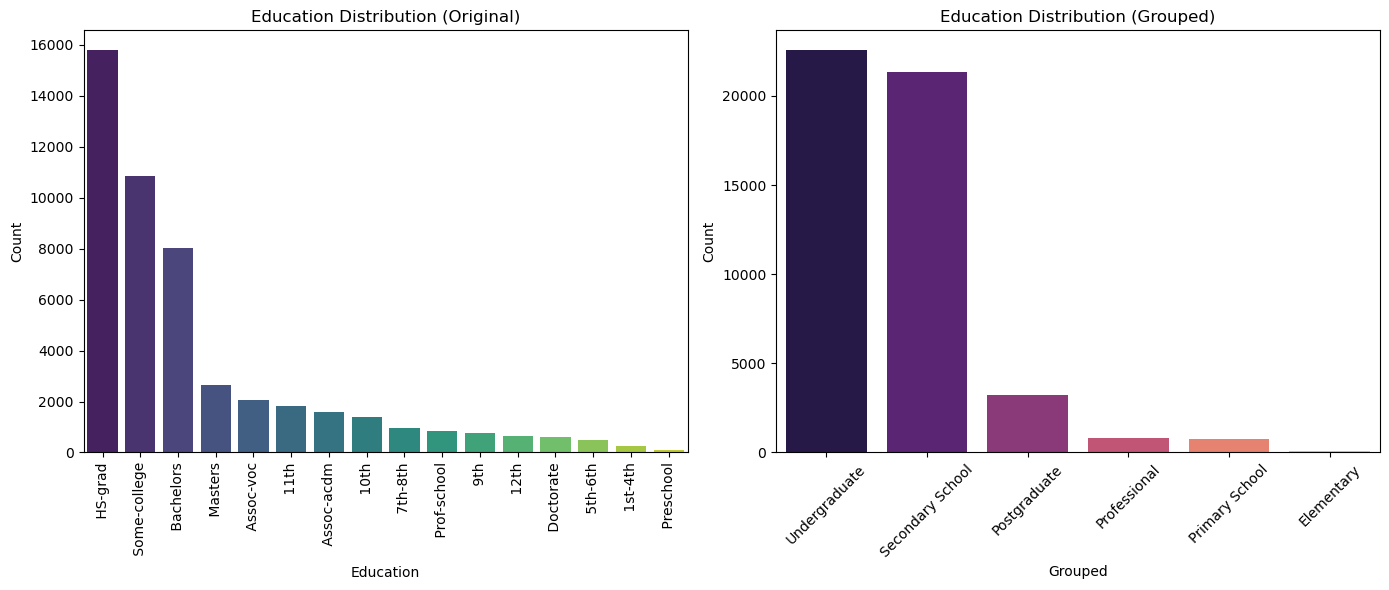

In [9]:
plt.figure(figsize=(14,6))

# Before grouping
plt.subplot(1,2,1)
sns.barplot(x=education_counts.index, y=education_counts.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Education Distribution (Original)")
plt.ylabel("Count")

# After grouping
plt.subplot(1,2,2)
sns.barplot(x=edu_group_counts.index, y=edu_group_counts.values, palette="magma")
plt.xticks(rotation=45)
plt.title("Education Distribution (Grouped)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Q2

In [10]:
# df["Age"].value_counts()
ages=df["Age"].unique()
print("ages:\n",ages)

hours=df['Hours_per_week'].unique()
print("hours:\n",hours)

ages:
 ['39' '50' '38' '53' '28' '37' '49' '52' '31' '42' '30' '23' '32' '40'
 '34' '25' '43' '54' '35' '59' '56' '19' '20' '45' '22' '48' '21' '24'
 '57' '44' '41' '29' '18' '47' '46' '36' '79' '27' '67' '33' '76' '17'
 '55' '61' '70' '64' '71' '68' '66' '51' '58' '26' '60' '90' '75' '65'
 '77' '62' '63' '80' '72' '74' '69' '73' '81' '78' '88' '82' '83' '84'
 '85' '86' '87' '|1x3 Cross validator' '89']
hours:
 [40. 13. 16. 45. 50. 80. 30. 35. 60. 20. 52. 44. 15. 25. 38. 43. 55. 48.
 58. 32. 70.  2. 22. 56. 41. 28. 36. 24. 46. 42. 12. 65.  1. 10. 34. 75.
 98. 33. 54.  8.  6. 64. 19. 18. 72.  5.  9. 47. 37. 21. 26. 14.  4. 59.
  7. 99. 53. 39. 62. 57. 78. 90. 66. 11. 49. 84.  3. 17. 68. 27. 85. 31.
 51. 77. 63. 23. 87. 88. 73. 89. 97. 94. 29. 96. 67. 82. 86. 91. 81. 76.
 92. 61. 74. 95. 79. 69.]


In [11]:
#numeric conversion
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
median_age = df["Age"].median()
df["Age"].fillna(median_age, inplace=True)
# print(df["Age"].isnull().sum())
df["Hours_per_week"] = pd.to_numeric(df["Hours_per_week"], errors="coerce")

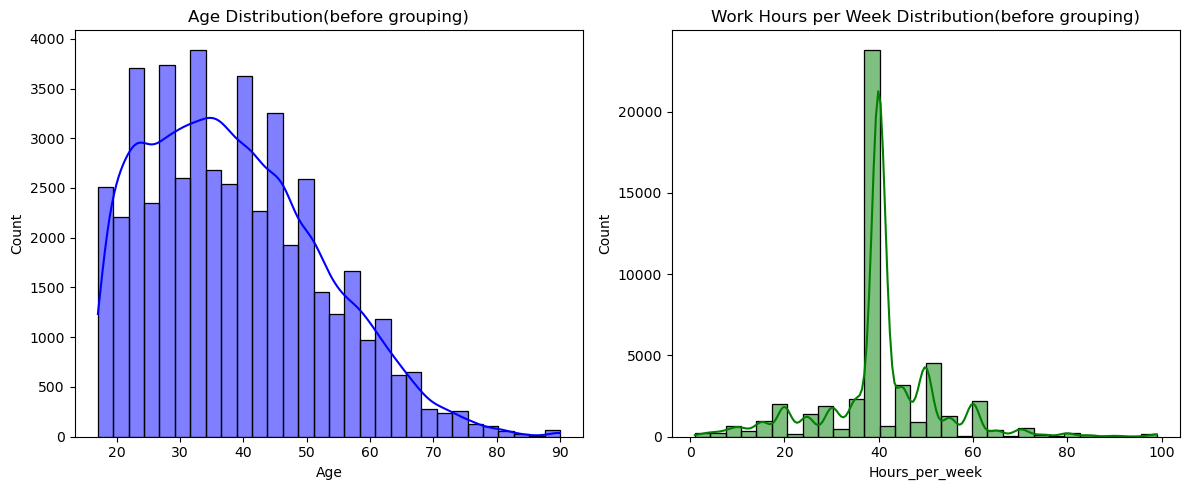

In [12]:
# 1. Distribution of Age & Hours
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Age"], bins=30, kde=True, color="blue")
plt.title("Age Distribution(before grouping)")

plt.subplot(1,2,2)
sns.histplot(df["Hours_per_week"], bins=30, kde=True, color="green")
plt.title("Work Hours per Week Distribution(before grouping)")

plt.tight_layout()
plt.show()

In [13]:
# Age Groups
df["Age_Group"] = pd.cut(df["Age"],
                         bins=[0, 18, 30, 45, 60, 100],
                         labels=["Teen", "Young Adult", "Adult", "Middle Age", "Senior"])

# Work Intensity Groups
df["Work_Intensity"] = pd.cut(df["Hours_per_week"],
                              bins=[0, 20, 40, 60, 100],
                              labels=["Part-time", "Full-time", "Overtime", "Extreme"])

/tmp/ipykernel_22633/2153414597.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Age_Group", data=df, palette="Blues")
/tmp/ipykernel_22633/2153414597.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Work_Intensity", data=df, palette="Greens")


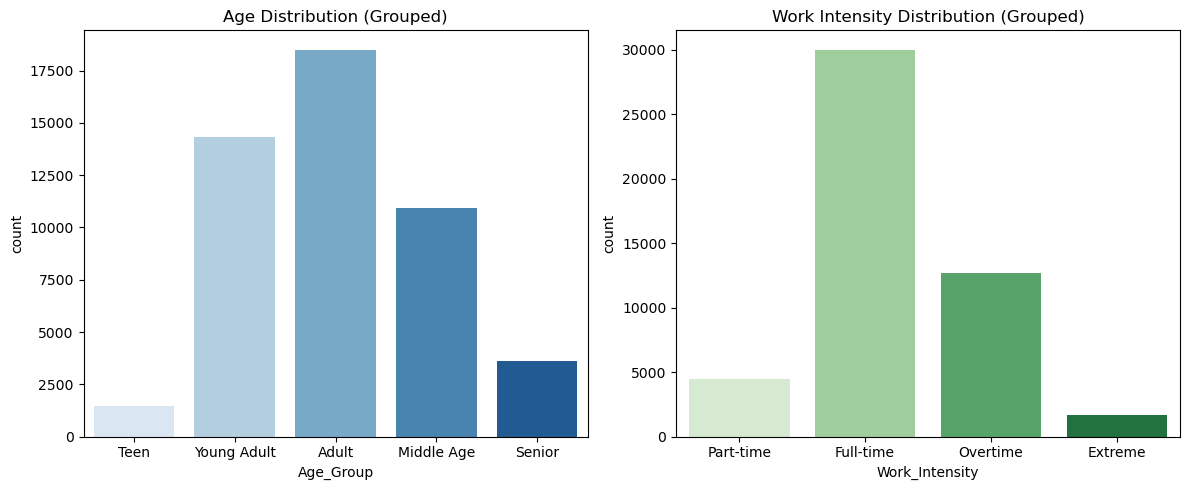

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x="Age_Group", data=df, palette="Blues")
plt.title("Age Distribution (Grouped)")

plt.subplot(1,2,2)
sns.countplot(x="Work_Intensity", data=df, palette="Greens")
plt.title("Work Intensity Distribution (Grouped)")

plt.tight_layout()
plt.show()

--- Analysis Before Grouping ---
Pearson Correlation Coefficient: 0.0713

--- Analysis After Grouping ---
Chi-Squared Statistic: 7250.66
P-value: 0.0


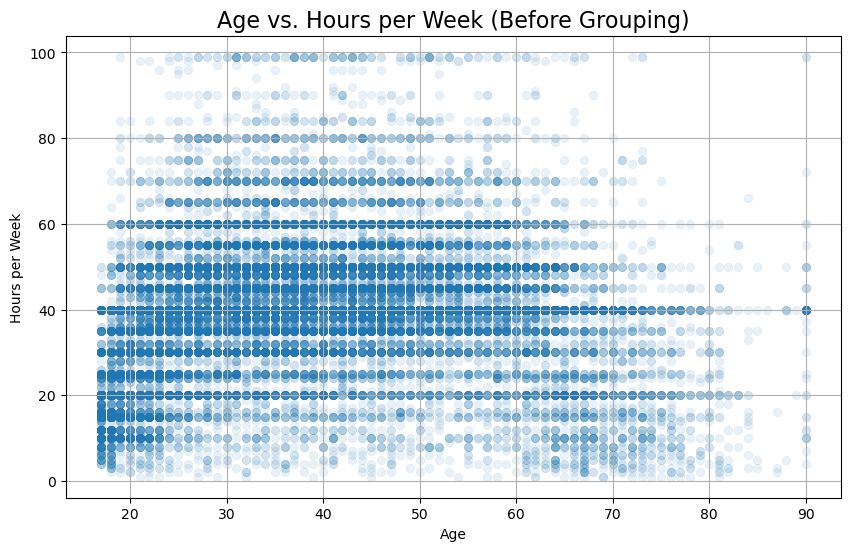

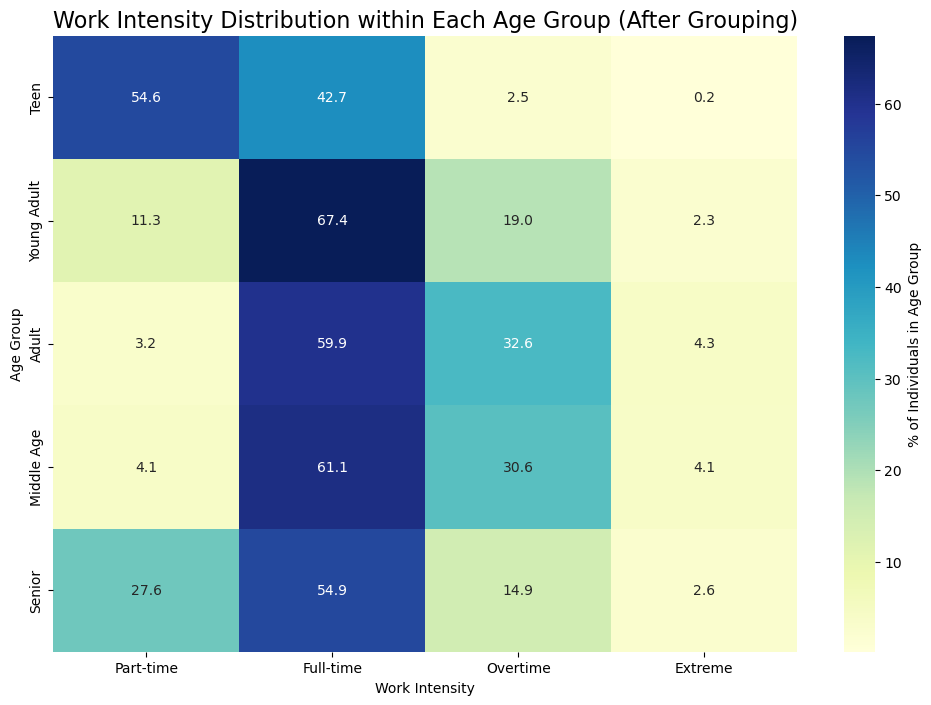

In [16]:
from scipy.stats import chi2_contingency
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Hours_per_week', data=df, alpha=0.1, edgecolor=None)
plt.title('Age vs. Hours per Week (Before Grouping)', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.grid(True)
plt.savefig('relationship_before_grouping.png')

# Statistical Evidence: Pearson correlation coefficient
correlation = df['Age'].corr(df['Hours_per_week'])
print(f"--- Analysis Before Grouping ---")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")


# --- 3. Analysis After Grouping (Categorical Variables) ---

# Apply the groupings
df["Age_Group"] = pd.cut(df["Age"], bins=[0, 18, 30, 45, 60, 100], labels=["Teen", "Young Adult", "Adult", "Middle Age", "Senior"])
df["Work_Intensity"] = pd.cut(df["Hours_per_week"], bins=[0, 20, 40, 60, 100], labels=["Part-time", "Full-time", "Overtime", "Extreme"])

# Statistical Evidence: Chi-Squared Test of Independence
crosstab_result = pd.crosstab(df['Age_Group'], df['Work_Intensity'])
chi2, p_value, dof, expected = chi2_contingency(crosstab_result)

print(f"\n--- Analysis After Grouping ---")
print(f"Chi-Squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value}")

# The heatmap from the previous question serves as the visualization for this part.
# We can re-generate it for clarity.
crosstab_norm = crosstab_result.apply(lambda r: r/r.sum()*100, axis=1)
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_norm, annot=True, cmap="YlGnBu", fmt='.1f', cbar_kws={'label': '% of Individuals in Age Group'})
plt.title('Work Intensity Distribution within Each Age Group (After Grouping)', fontsize=16)
plt.ylabel('Age Group')
plt.xlabel('Work Intensity')
plt.savefig('relationship_after_grouping_heatmap.png')

In [18]:
corr = df["Age"].corr(df["Hours_per_week"])
print("Correlation between Age and Hours per week (before grouping):", corr)

Correlation between Age and Hours per week (before grouping): 0.07132180416031979


In [19]:
from scipy.stats import chi2_contingency

# Crosstab (counts)
crosstab = pd.crosstab(df["Age_Group"], df["Work_Intensity"])
print("\nCrosstab:\n", crosstab)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(crosstab)
print("\nChi-square test result:")
print("Chi2 statistic =", chi2)
print("p-value =", p)

if p < 0.05:
    print("=> Significant association between Age Group and Work Intensity")
else:
    print("=> No significant association found")


Crosstab:
 Work_Intensity  Part-time  Full-time  Overtime  Extreme
Age_Group                                              
Teen                  795        621        37        3
Young Adult          1615       9654      2718      332
Adult                 595      11080      6032      793
Middle Age            448       6685      3348      453
Senior                995       1979       536       95

Chi-square test result:
Chi2 statistic = 7250.659759408522
p-value = 0.0
=> Significant association between Age Group and Work Intensity


# Q3

In [20]:
gain=df["Capital_Gain"].unique()
print("gain:\n",gain)

loss=df['Capital_Loss'].unique()
print("loss:\n",loss)

gain:
 [ 2174.     0. 14084.  5178.  5013.  2407. 14344. 15024.  7688. 34095.
  4064.  4386.  7298.  1409.  3674.  1055.  3464.  2050.  2176.   594.
 20051.  6849.  4101.  1111.  8614.  3411.  2597. 25236.  4650.  9386.
  2463.  3103. 10605.  2964.  3325.  2580.  3471.  4865. 99999.  6514.
  1471.  2329.  2105.  2885. 25124. 10520.  2202.  2961. 27828.  6767.
  2228.  1506. 13550.  2635.  5556.  4787.  3781.  3137.  3818.  3942.
   914.   401.  2829.  2977.  4934.  2062.  2354.  5455. 15020.  1424.
  3273. 22040.  4416.  3908. 10566.   991.  4931.  1086.  7430.  6497.
   114.  7896.  2346.  3418.  3432.  2907.  1151.  2414.  2290. 15831.
 41310.  4508.  2538.  3456.  6418.  1848.  3887.  5721.  9562.  1455.
  2036.  1831. 11678.  2936.  2993.  7443.  6360.  1797.  1173.  4687.
  6723.  2009.  6097.  2653.  1639. 18481.  7978.  2387.  5060.  1264.
  7262.  1731.  6612.]
loss:
 [   0. 2042. 1408. 1902. 1573. 1887. 1719. 1762. 1564. 2179. 1816. 1980.
 1977. 1876. 1340. 2206. 1741. 1485. 2

In [21]:
df["Capital_Gain"] = pd.to_numeric(df["Capital_Gain"], errors="coerce")
df["Capital_Loss"] = pd.to_numeric(df["Capital_Loss"], errors="coerce")

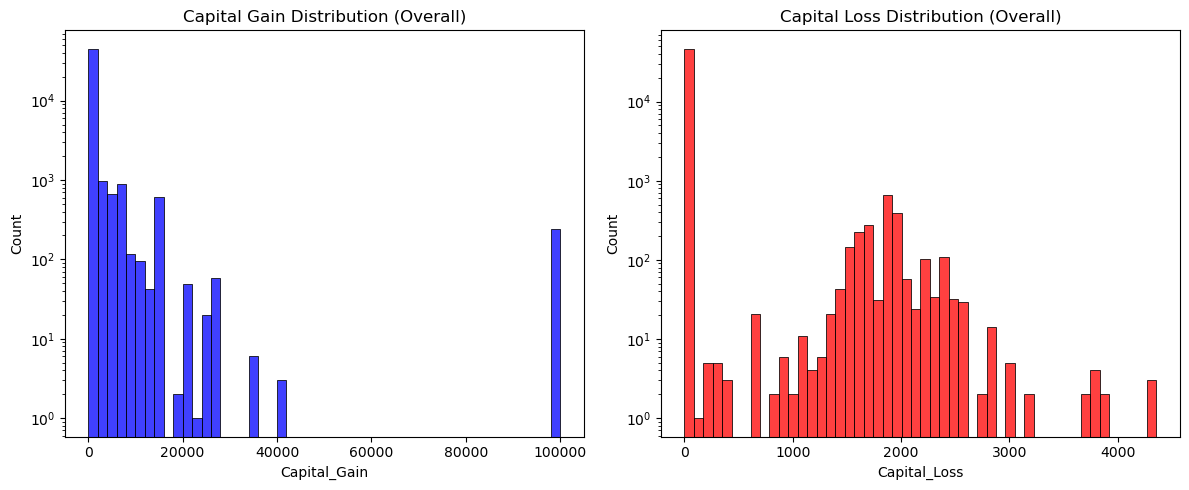

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Capital_Gain"], bins=50, color="blue")
plt.yscale("log")
plt.title("Capital Gain Distribution (Overall)")

plt.subplot(1,2,2)
sns.histplot(df["Capital_Loss"], bins=50, color="red")
plt.yscale("log")
plt.title("Capital Loss Distribution (Overall)")

plt.tight_layout()
plt.show()

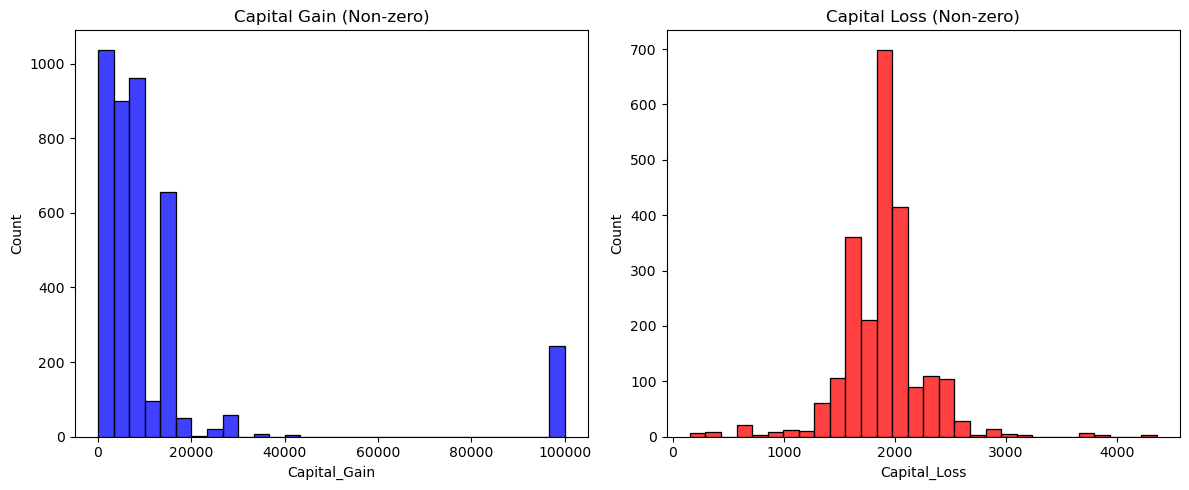

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[df["Capital_Gain"] > 0]["Capital_Gain"], bins=30, color="blue")
plt.title("Capital Gain (Non-zero)")

plt.subplot(1,2,2)
sns.histplot(df[df["Capital_Loss"] > 0]["Capital_Loss"], bins=30, color="red")
plt.title("Capital Loss (Non-zero)")

plt.tight_layout()
plt.show()

In [24]:
#  Proportion with Capital Activity

df["Capital_Activity"] = ((df["Capital_Gain"] > 0) | (df["Capital_Loss"] > 0)).astype(int)
activity_rate = df["Capital_Activity"].mean() * 100
print(f"Proportion of individuals with any capital activity: {activity_rate:.2f}%")

Proportion of individuals with any capital activity: 12.94%


In [25]:
df["Net_Capital"] = df["Capital_Gain"] - df["Capital_Loss"]

# Group by Age
age_summary = df.groupby("Age_Group").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
age_summary["Capital_Activity_Rate"] *= 100

# Group by Work Intensity
work_summary = df.groupby("Work_Intensity").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
work_summary["Capital_Activity_Rate"] *= 100

print("\nAverage Net Capital and Activity Rate by Age Group:\n", age_summary)
print("\nAverage Net Capital and Activity Rate by Work Intensity:\n", work_summary)



Average Net Capital and Activity Rate by Age Group:
      Age_Group  Avg_Net_Capital  Capital_Activity_Rate
0         Teen        42.273352               4.807692
1  Young Adult       265.960193               7.032614
2        Adult      1066.270270              14.562162
3   Middle Age      1743.911835              16.791659
4       Senior      1599.519279              19.694868

Average Net Capital and Activity Rate by Work Intensity:
   Work_Intensity  Avg_Net_Capital  Capital_Activity_Rate
0      Part-time       296.176034               8.228417
1      Full-time       644.559612              11.036344
2       Overtime      1832.709336              18.372662
3        Extreme      2709.634248              18.496420


/tmp/ipykernel_22633/2496942606.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby("Age_Group").agg(
/tmp/ipykernel_22633/2496942606.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_summary = df.groupby("Work_Intensity").agg(


/tmp/ipykernel_22633/3982128043.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby("Age_Group").agg(
/tmp/ipykernel_22633/3982128043.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_summary = df.groupby("Work_Intensity").agg(
/tmp/ipykernel_22633/3982128043.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Age_Group", y="Avg_Net_Capital", data=age_summary, palette="Blues", ax=ax1)
/tmp/ipykernel_22633/3982128043.py:31: F

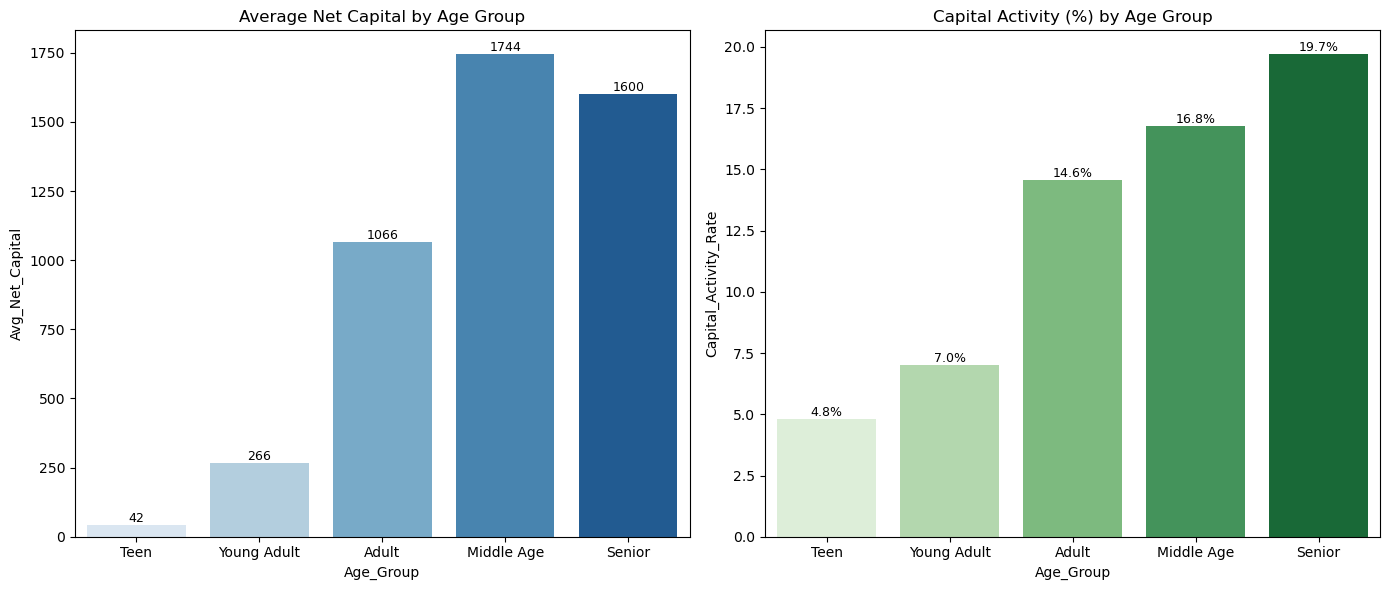

/tmp/ipykernel_22633/3982128043.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Work_Intensity", y="Avg_Net_Capital", data=work_summary, palette="Purples", ax=ax3)
/tmp/ipykernel_22633/3982128043.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Work_Intensity", y="Capital_Activity_Rate", data=work_summary, palette="Oranges", ax=ax4)


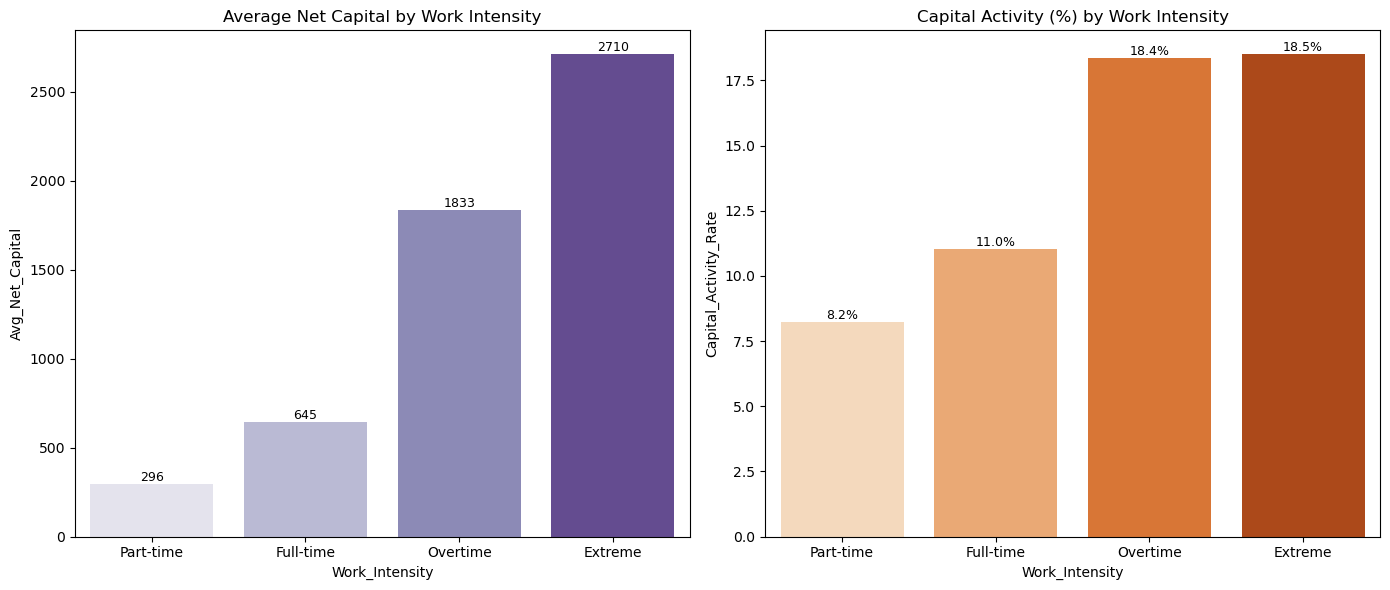

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Net Capital
df["Net_Capital"] = df["Capital_Gain"] - df["Capital_Loss"]

# Group by Age
age_summary = df.groupby("Age_Group").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
age_summary["Capital_Activity_Rate"] *= 100

# Group by Work Intensity
work_summary = df.groupby("Work_Intensity").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
work_summary["Capital_Activity_Rate"] *= 100

# ---- Plot Age Summary ----
plt.figure(figsize=(14,6))

ax1 = plt.subplot(1,2,1)
sns.barplot(x="Age_Group", y="Avg_Net_Capital", data=age_summary, palette="Blues", ax=ax1)
ax1.set_title("Average Net Capital by Age Group")
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.0f", fontsize=9)

ax2 = plt.subplot(1,2,2)
sns.barplot(x="Age_Group", y="Capital_Activity_Rate", data=age_summary, palette="Greens", ax=ax2)
ax2.set_title("Capital Activity (%) by Age Group")
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()

# ---- Plot Work Summary ----
plt.figure(figsize=(14,6))

ax3 = plt.subplot(1,2,1)
sns.barplot(x="Work_Intensity", y="Avg_Net_Capital", data=work_summary, palette="Purples", ax=ax3)
ax3.set_title("Average Net Capital by Work Intensity")
for container in ax3.containers:
    ax3.bar_label(container, fmt="%.0f", fontsize=9)

ax4 = plt.subplot(1,2,2)
sns.barplot(x="Work_Intensity", y="Capital_Activity_Rate", data=work_summary, palette="Oranges", ax=ax4)
ax4.set_title("Capital Activity (%) by Work Intensity")
for container in ax4.containers:
    ax4.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()


## Association of Age and Work Intensity with Net Capital¶


In [27]:
corr_age = df["Age"].corr(df["Net_Capital"])
corr_hours = df["Hours_per_week"].corr(df["Net_Capital"])

print("Correlation (Age vs Net Capital):", corr_age)
print("Correlation (Work Hours vs Net Capital):", corr_hours)

Correlation (Age vs Net Capital): 0.07391044914801059
Correlation (Work Hours vs Net Capital): 0.07896085263220065


In [28]:
age_summary = df.groupby("Age_Group")["Net_Capital"].mean()
work_summary = df.groupby("Work_Intensity")["Net_Capital"].mean()
print("Average Net Capital by Age Group:\n", age_summary)
print("\nAverage Net Capital by Work Intensity:\n", work_summary)

Average Net Capital by Age Group:
 Age_Group
Teen             42.273352
Young Adult     265.960193
Adult          1066.270270
Middle Age     1743.911835
Senior         1599.519279
Name: Net_Capital, dtype: float64

Average Net Capital by Work Intensity:
 Work_Intensity
Part-time     296.176034
Full-time     644.559612
Overtime     1832.709336
Extreme      2709.634248
Name: Net_Capital, dtype: float64


/tmp/ipykernel_22633/3008485645.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby("Age_Group")["Net_Capital"].mean()
/tmp/ipykernel_22633/3008485645.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_summary = df.groupby("Work_Intensity")["Net_Capital"].mean()


In [29]:
from scipy.stats import f_oneway

# Drop NA groups
age_groups = [df.loc[df["Age_Group"]==grp, "Net_Capital"].dropna() for grp in df["Age_Group"].unique()]
work_groups = [df.loc[df["Work_Intensity"]==grp, "Net_Capital"].dropna() for grp in df["Work_Intensity"].unique()]

f_age, p_age = f_oneway(*age_groups)
f_work, p_work = f_oneway(*work_groups)

print("ANOVA (Age Groups): F =", f_age, "p =", p_age)
print("ANOVA (Work Intensity Groups): F =", f_work, "p =", p_work)

ANOVA (Age Groups): F = 74.1047182362599 p = 9.984044242580964e-63
ANOVA (Work Intensity Groups): F = 118.15137313860703 p = 3.0603147553955086e-76


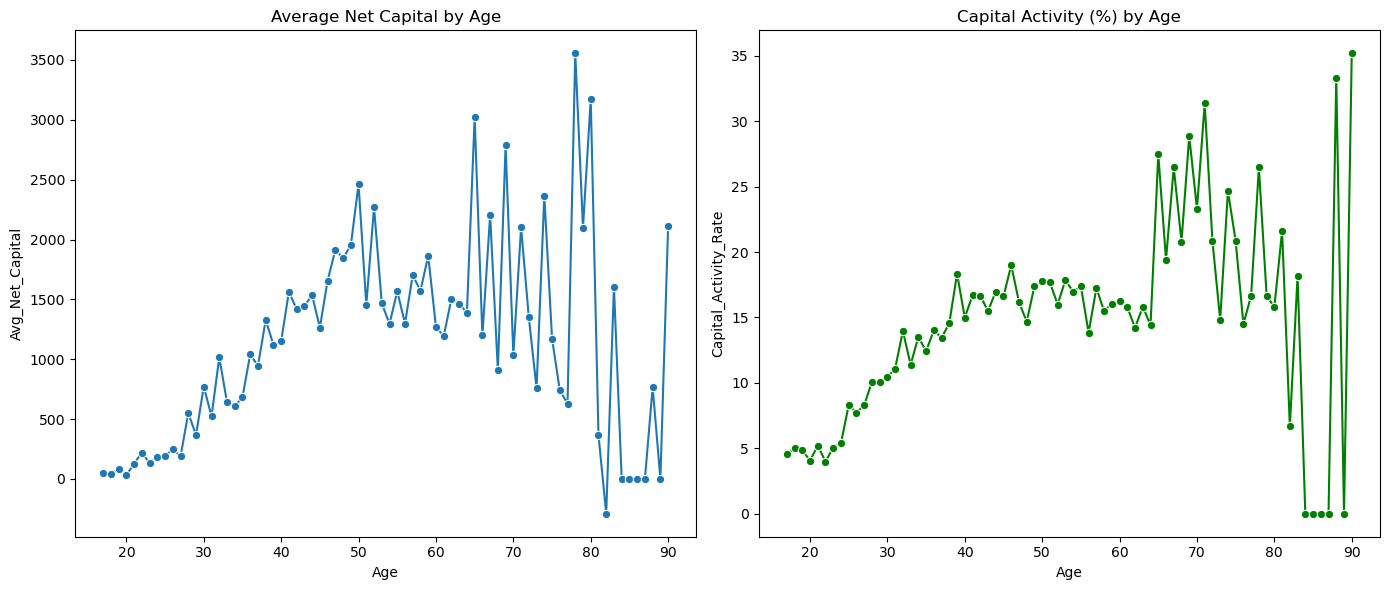

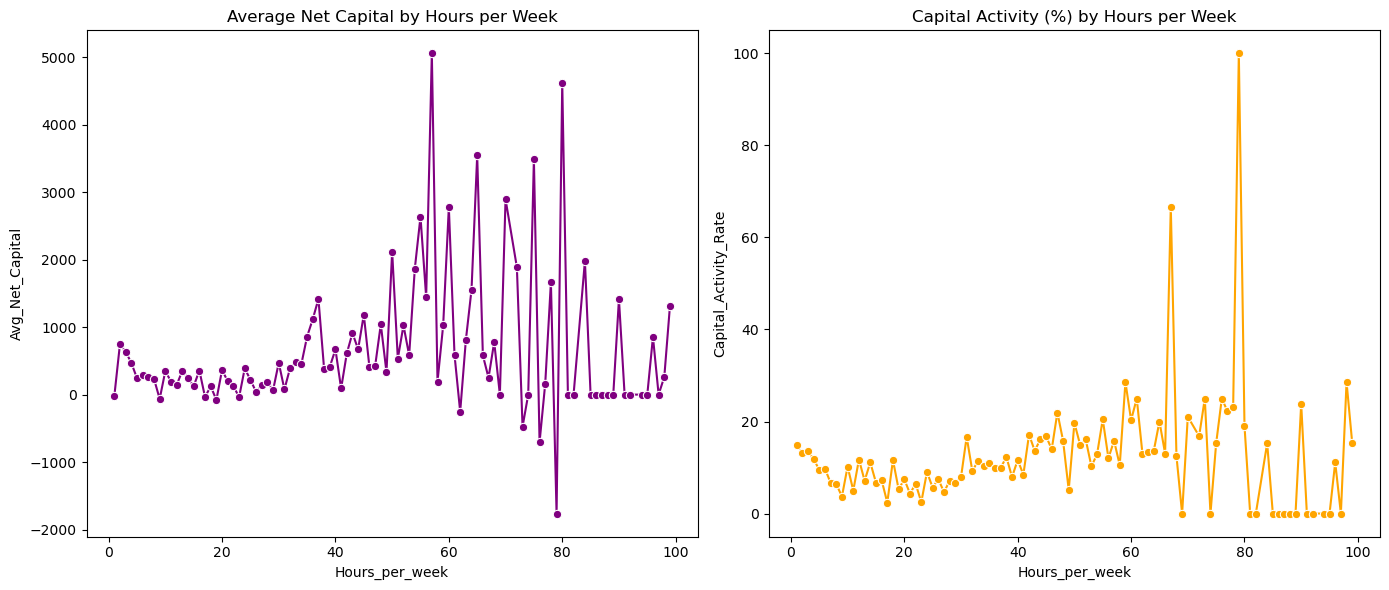

In [30]:
# Group by Age
age_summary = df.groupby("Age").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
age_summary["Capital_Activity_Rate"] *= 100

# Group by Hours per Week
work_summary = df.groupby("Hours_per_week").agg(
    Avg_Net_Capital=("Net_Capital", "mean"),
    Capital_Activity_Rate=("Capital_Activity", "mean")
).reset_index()
work_summary["Capital_Activity_Rate"] *= 100

# ---- Plot Age Summary ----
plt.figure(figsize=(14,6))

ax1 = plt.subplot(1,2,1)
sns.lineplot(x="Age", y="Avg_Net_Capital", data=age_summary, marker="o", ax=ax1)
ax1.set_title("Average Net Capital by Age")


ax2 = plt.subplot(1,2,2)
sns.lineplot(x="Age", y="Capital_Activity_Rate", data=age_summary, marker="o", ax=ax2, color="green")
ax2.set_title("Capital Activity (%) by Age")


plt.tight_layout()
plt.show()

# ---- Plot Hours per Week Summary ----
plt.figure(figsize=(14,6))

ax3 = plt.subplot(1,2,1)
sns.lineplot(x="Hours_per_week", y="Avg_Net_Capital", data=work_summary, marker="o", ax=ax3, color="purple")
ax3.set_title("Average Net Capital by Hours per Week")


ax4 = plt.subplot(1,2,2)
sns.lineplot(x="Hours_per_week", y="Capital_Activity_Rate", data=work_summary, marker="o", ax=ax4, color="orange")
ax4.set_title("Capital Activity (%) by Hours per Week")


plt.tight_layout()
plt.show()